**Wholesale Customers Clustering**

 Customer segmentation using clustering techniques on wholesale spending data

## 1 - Load dataset

In [32]:
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.cluster import AgglomerativeClustering,DBSCAN
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA

In [2]:
customer_df = pd.read_csv("./Wholesale_customers_data.csv")

In [3]:
customer_df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


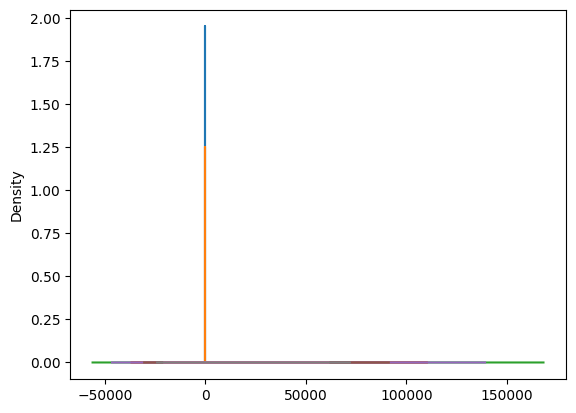

In [5]:
for column in customer_df :
 
 customer_df[column].plot(kind='kde')

## 2 - Feature Distribution

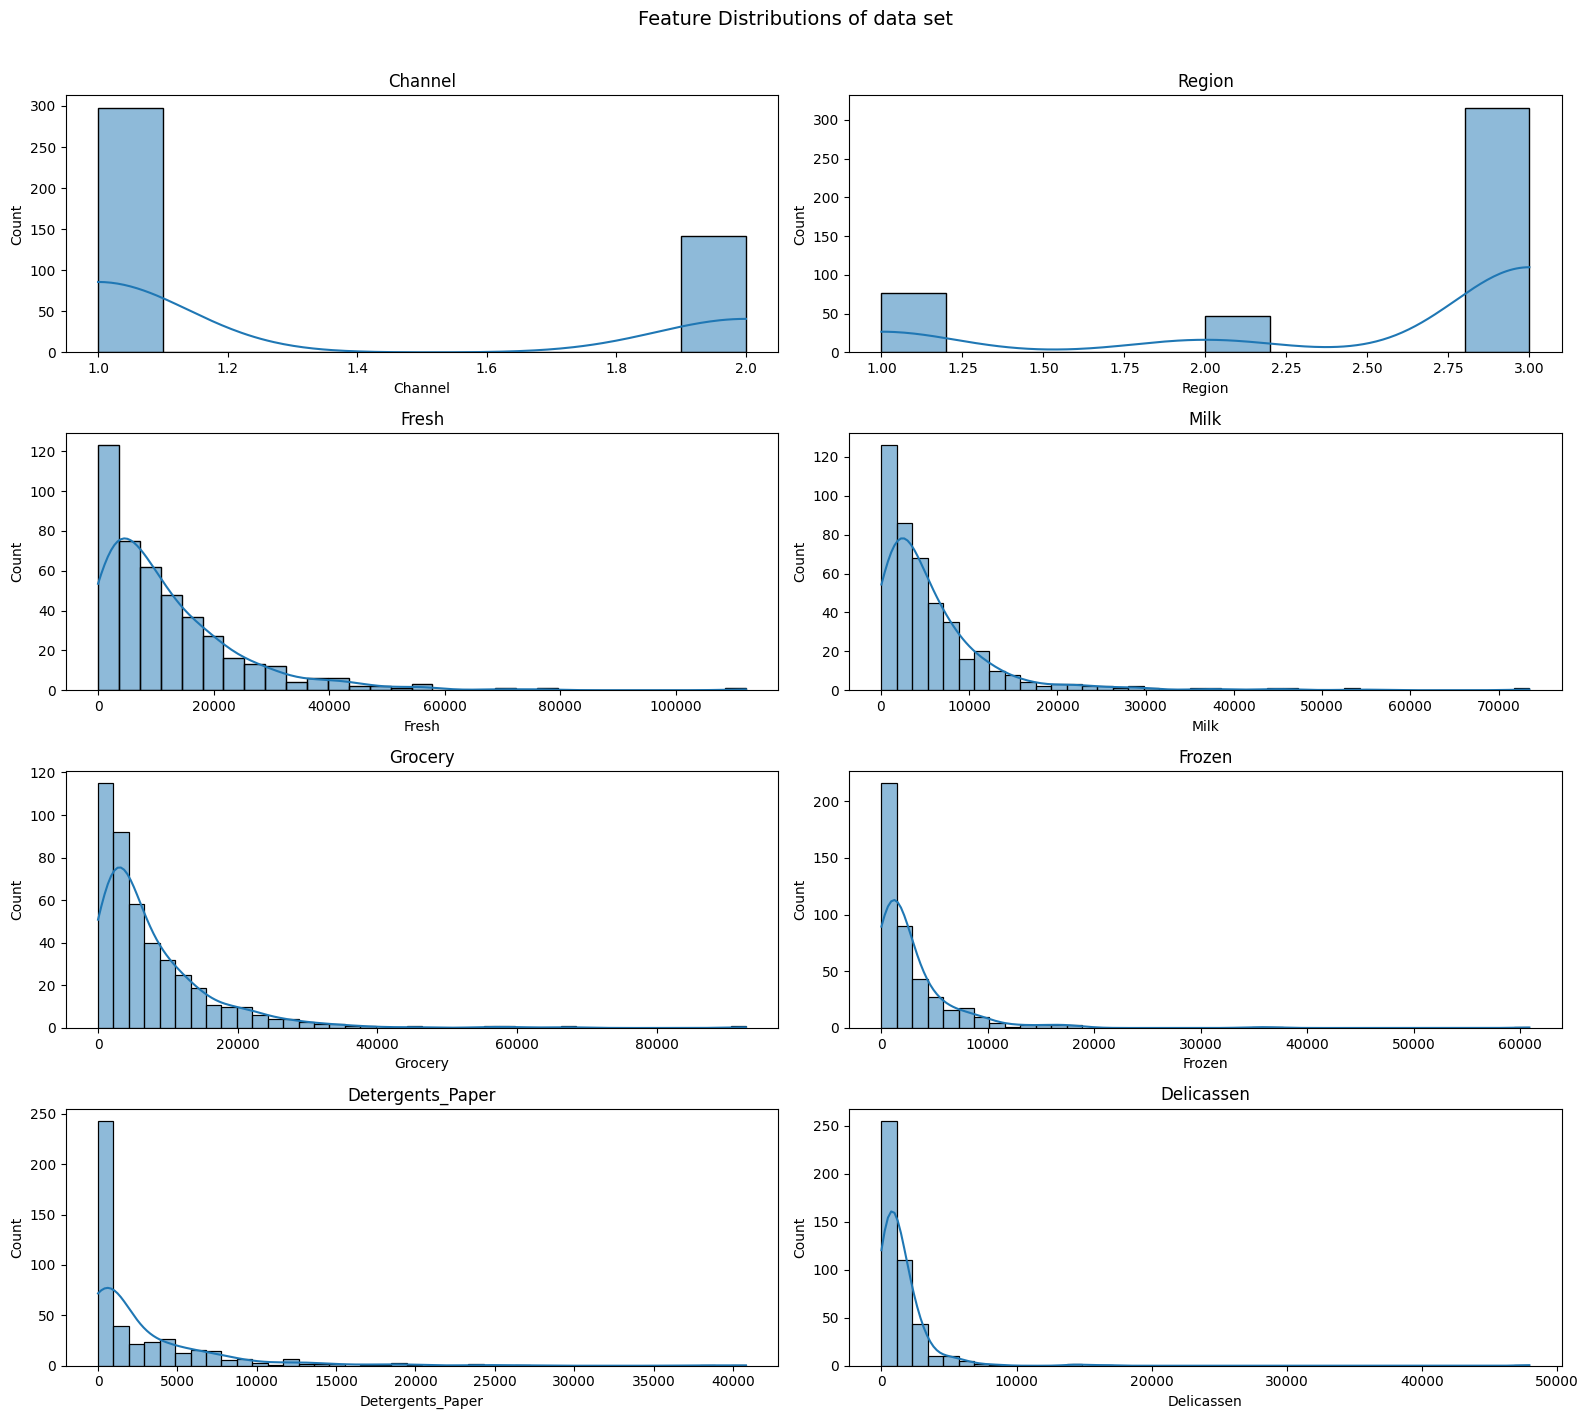

In [6]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for i, col in enumerate(customer_df.columns):
    sns.histplot(data=customer_df, x=col, kde=True, ax=axes_flat[i]
                 , common_norm=False, alpha=0.5)
    axes_flat[i].set_title(col)



plt.suptitle('Feature Distributions of data set', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

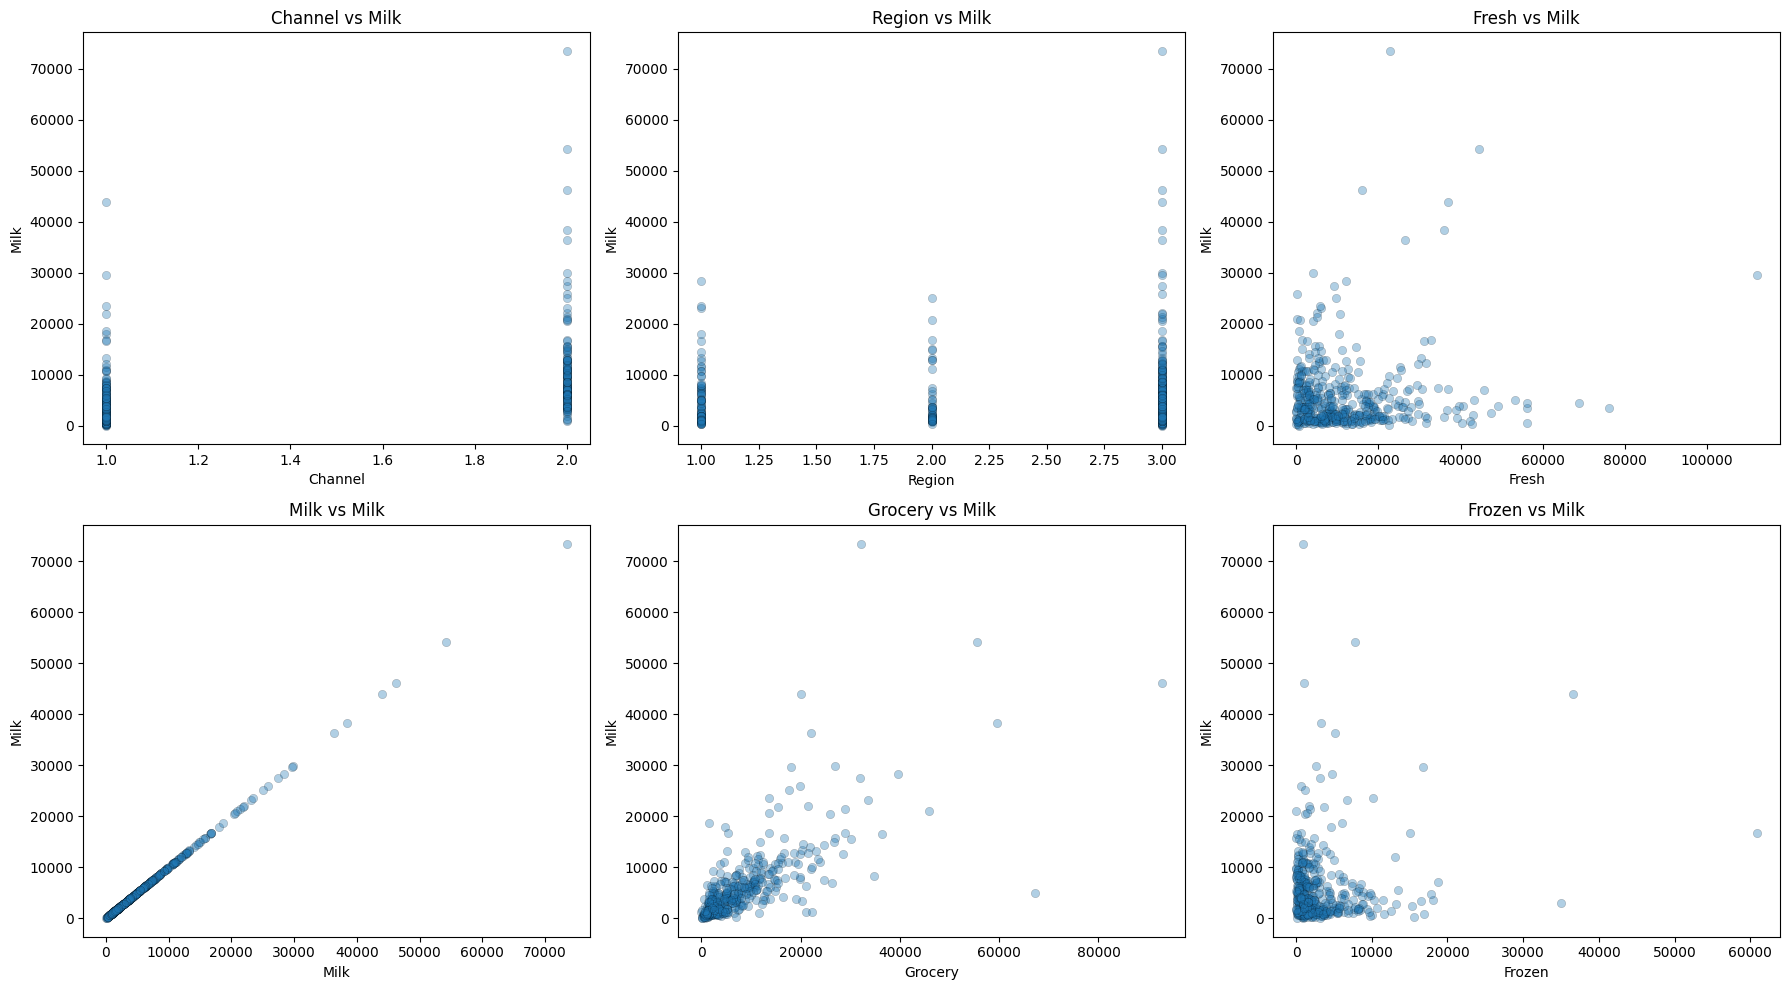

In [7]:
scatter_features = customer_df.columns

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feat in zip(axes.ravel(), scatter_features):
    ax.scatter(customer_df[feat], customer_df['Milk'], alpha=0.35, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(feat)
    ax.set_ylabel('Milk')
    ax.set_title(f'{feat} vs Milk')
plt.tight_layout()
plt.show()

<Axes: >

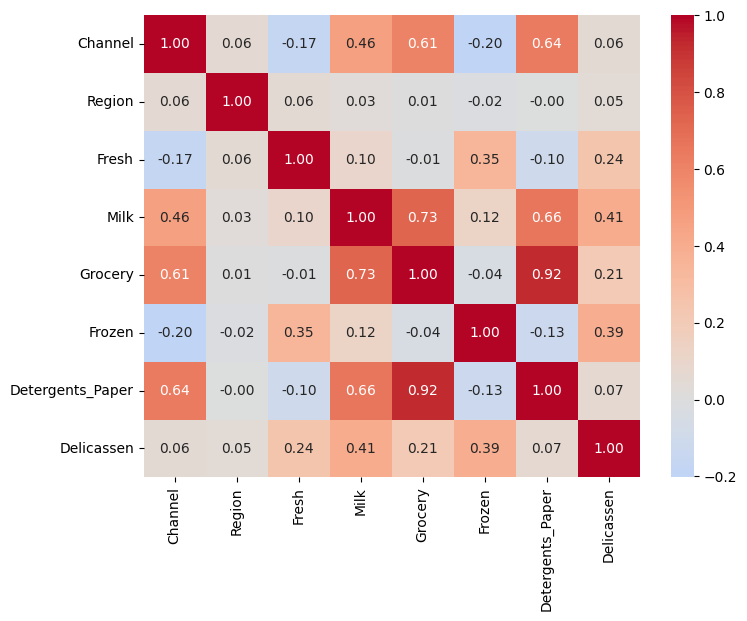

In [8]:
corr_matrix = customer_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,        # Show correlation values
    cmap='coolwarm',   # Color map
    center=0,          # Center at zero
    fmt=".2f"          # Format numbers
)

## 3 - Preprocessing

In [9]:
print('Skewness of spending features:')
print(customer_df.skew().round(2))

Skewness of spending features:
Channel              0.76
Region              -1.28
Fresh                2.56
Milk                 4.05
Grocery              3.59
Frozen               5.91
Detergents_Paper     3.63
Delicassen          11.15
dtype: float64


**Log Trasformation**

In [10]:
class_cols = ['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen']

customer_df_log = customer_df.copy()

for col in class_cols:
    customer_df_log[col] = np.log1p(customer_df[col])

print('Skewness after log-transform:')
print(customer_df_log[class_cols].skew().round(2))

Skewness after log-transform:
Fresh              -1.58
Milk               -0.22
Grocery            -0.67
Frozen             -0.35
Detergents_Paper   -0.24
Delicassen         -1.09
dtype: float64


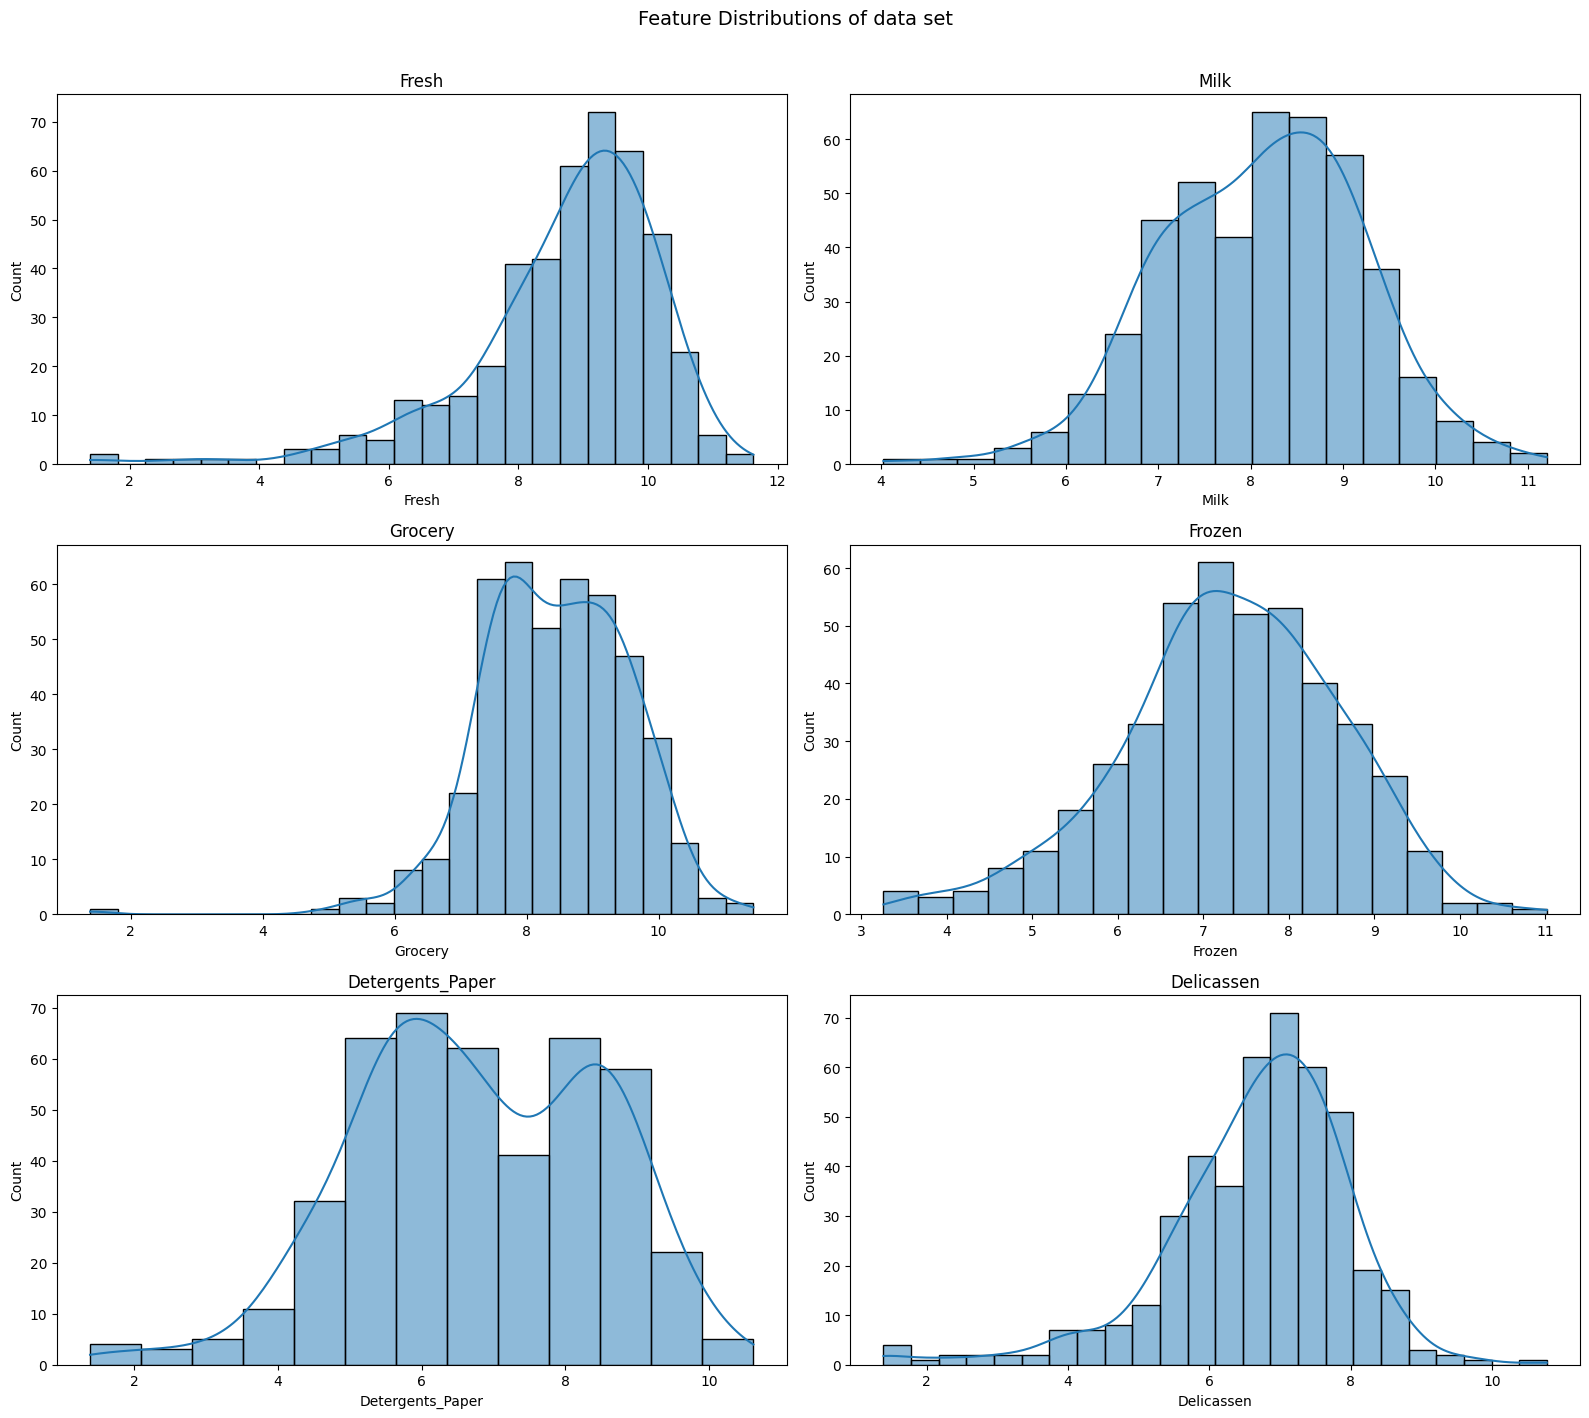

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for i, col in enumerate(class_cols):
    sns.histplot(data=customer_df_log, x=col, kde=True, ax=axes_flat[i]
                 , common_norm=False, alpha=0.5)
    axes_flat[i].set_title(col)



plt.suptitle('Feature Distributions of data set', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

**Feature Scaling**

In [12]:
scaler = StandardScaler()
X = scaler.fit_transform(customer_df_log[class_cols])
print(f'Feature matrix shape: {X.shape}')

Feature matrix shape: (440, 6)


## 4 Clustering Algorithms

**K-Means Clusterting**

In [13]:
k = list(range(2, 11))
silhouette_avgs = []
wcss_list = []

for n_clusters in k:
    kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X)
    sil_avg = silhouette_score(X, cluster_labels)
    silhouette_avgs.append(sil_avg)
    wcss = kmeans.inertia_
    wcss_list.append(wcss)
    print(f"For n_clusters = {n_clusters}, average silhouette_score = {sil_avg:.3f}, inertia ={wcss:.2f}")

For n_clusters = 2, average silhouette_score = 0.290, inertia =1844.06
For n_clusters = 3, average silhouette_score = 0.259, inertia =1553.42
For n_clusters = 4, average silhouette_score = 0.188, inertia =1386.86
For n_clusters = 5, average silhouette_score = 0.192, inertia =1266.15
For n_clusters = 6, average silhouette_score = 0.201, inertia =1174.76
For n_clusters = 7, average silhouette_score = 0.196, inertia =1086.36
For n_clusters = 8, average silhouette_score = 0.185, inertia =1028.49
For n_clusters = 9, average silhouette_score = 0.197, inertia =973.14
For n_clusters = 10, average silhouette_score = 0.191, inertia =932.00


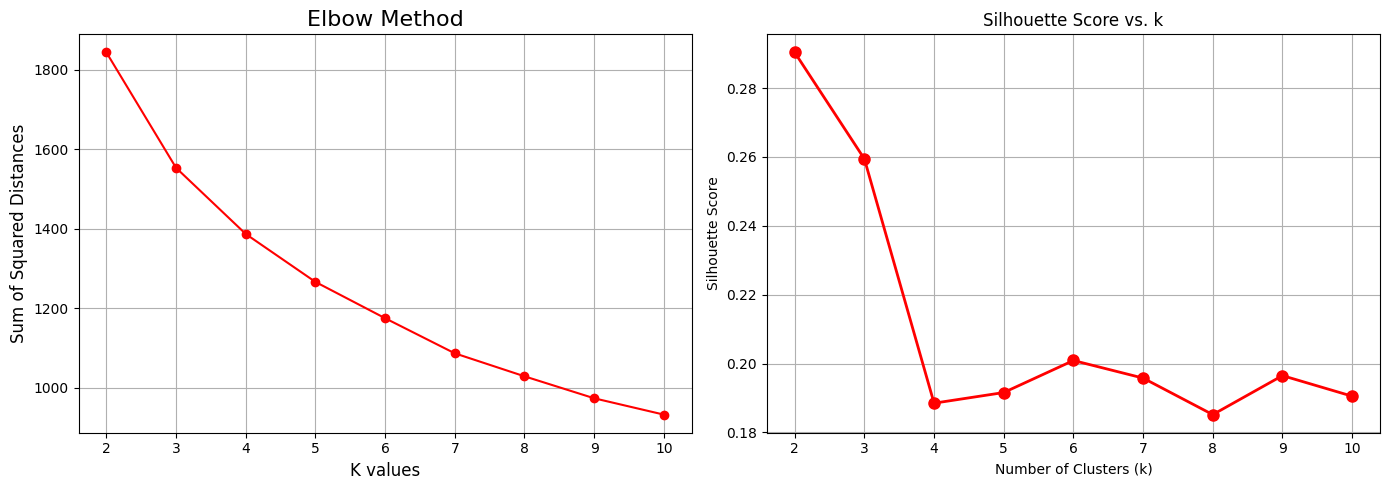

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k, wcss_list, "ro-")
axes[0].set_xlabel("K values", fontsize=12)
axes[0].set_ylabel("Sum of Squared Distances",fontsize=12)
axes[0].set_title("Elbow Method",fontsize=16)
axes[0].grid(True)

axes[1].plot(k, silhouette_avgs, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs. k')
axes[1].grid(True)

plt.tight_layout()
plt.show()

kMeans clustering with n_clusters =2 and 3

In [15]:
model = KMeans(n_clusters=2)
model.fit(X)
labels = model.predict(X)
centroids = model.cluster_centers_

**Plot the output of kMeans clustering =2**

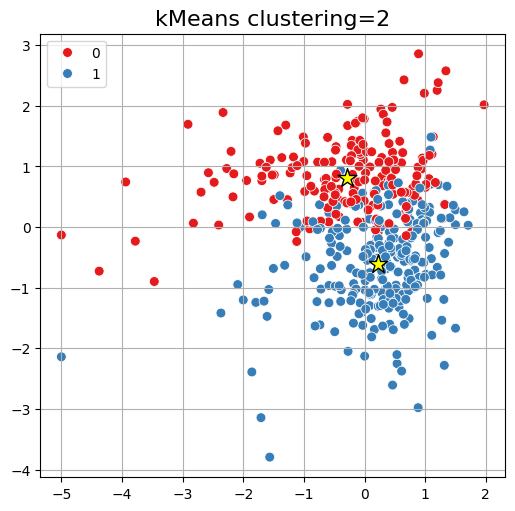

In [16]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1', s=50)
plt.scatter(centroids[:,0], centroids[:,1], c='yellow', s=200, marker='*', edgecolor='k')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.grid()
plt.title("kMeans clustering=2", fontsize=16)
plt.show()

In [17]:
model_k3 = KMeans(n_clusters=3)
model_k3.fit(X)
labels_k3 = model_k3.predict(X)
centroids_k3 = model_k3.cluster_centers_

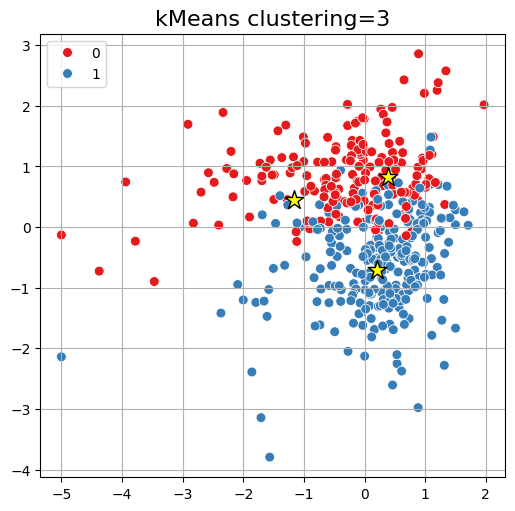

In [18]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels, palette='Set1', s=50)
plt.scatter(centroids_k3[:,0], centroids_k3[:,1], c='yellow', s=200, marker='*', edgecolor='k')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.grid()
plt.title("kMeans clustering=3", fontsize=16)
plt.show()

In [19]:
km_2 = KMeans(n_clusters=2, n_init=10, random_state=402)
km_3 = KMeans(n_clusters=3, n_init=10, random_state=402)

labels_km2 = km_2.fit_predict(X)
labels_km3 = km_3.fit_predict(X)

print(f'K-Means (k=2) — Silhouette: {silhouette_score(X, labels_km2):.4f}')
print(f'K-Means (k=3) — Silhouette: {silhouette_score(X, labels_km3):.4f}')
print(f'\nCluster sizes (k=2): {np.bincount(labels_km2)}')
print(f'Cluster sizes (k=3): {np.bincount(labels_km3)}')

K-Means (k=2) — Silhouette: 0.2903
K-Means (k=3) — Silhouette: 0.2594

Cluster sizes (k=2): [188 252]
Cluster sizes (k=3): [ 80 215 145]


**Hierarchical Clustering**

In [20]:
agg_cluster = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_pred_agg = agg_cluster.fit_predict(X)

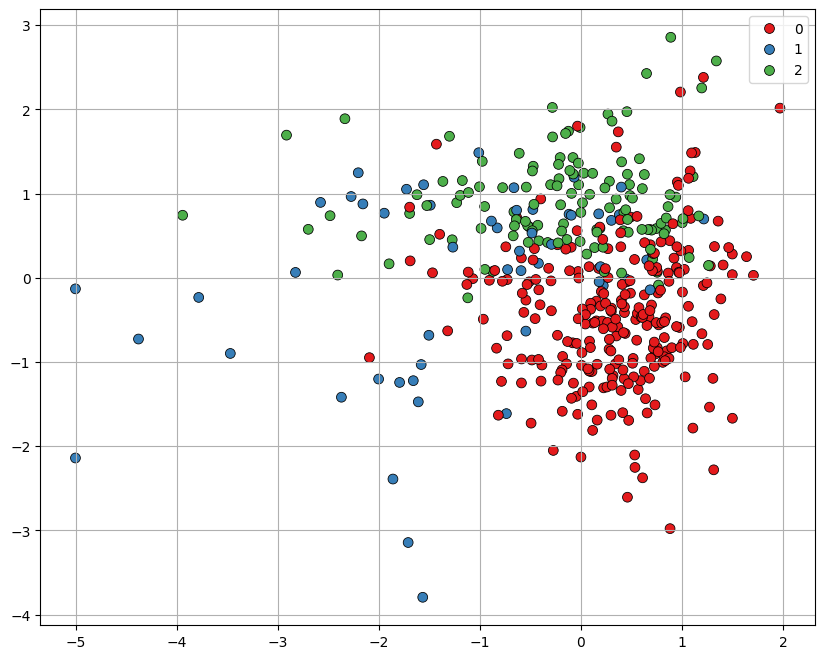

In [21]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_agg, palette='Set1', s=50, edgecolor='k')
plt.grid()
plt.show()

In [22]:
print(f'Agglomerative (k=3) — Silhouette: {silhouette_score(X, y_pred_agg, metric='euclidean'):.4f}')



Agglomerative (k=3) — Silhouette: 0.2547


In [23]:
agg_cluster_c2 = AgglomerativeClustering(n_clusters=2, linkage='ward')
y_pred_agg_c2 = agg_cluster_c2.fit_predict(X)

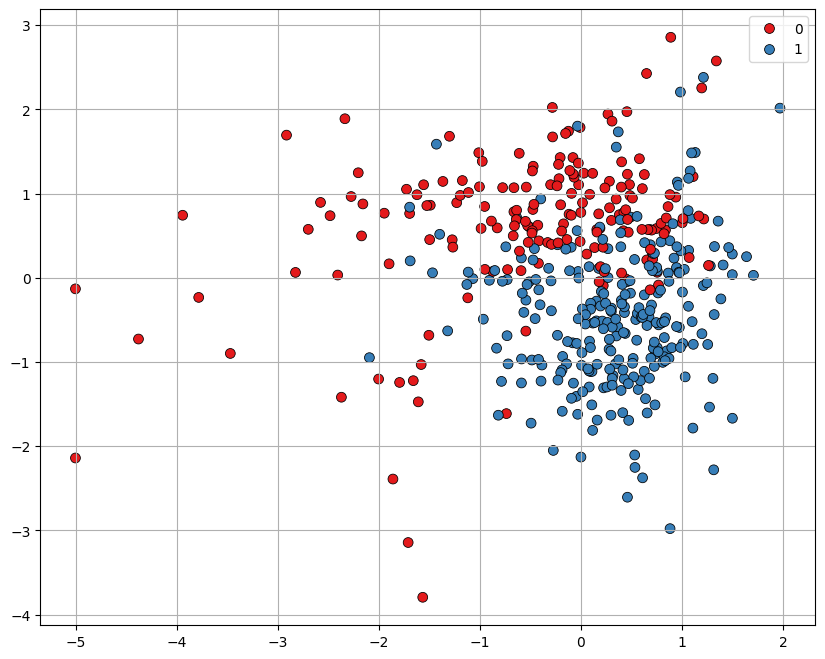

In [24]:
plt.figure(figsize=(10,8))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=y_pred_agg_c2, palette='Set1', s=50, edgecolor='k')
plt.grid()
plt.show()

In [25]:
print(f'Agglomerative (k=2) — Silhouette: {silhouette_score(X, y_pred_agg_c2, metric='euclidean'):.4f}')


Agglomerative (k=2) — Silhouette: 0.2585


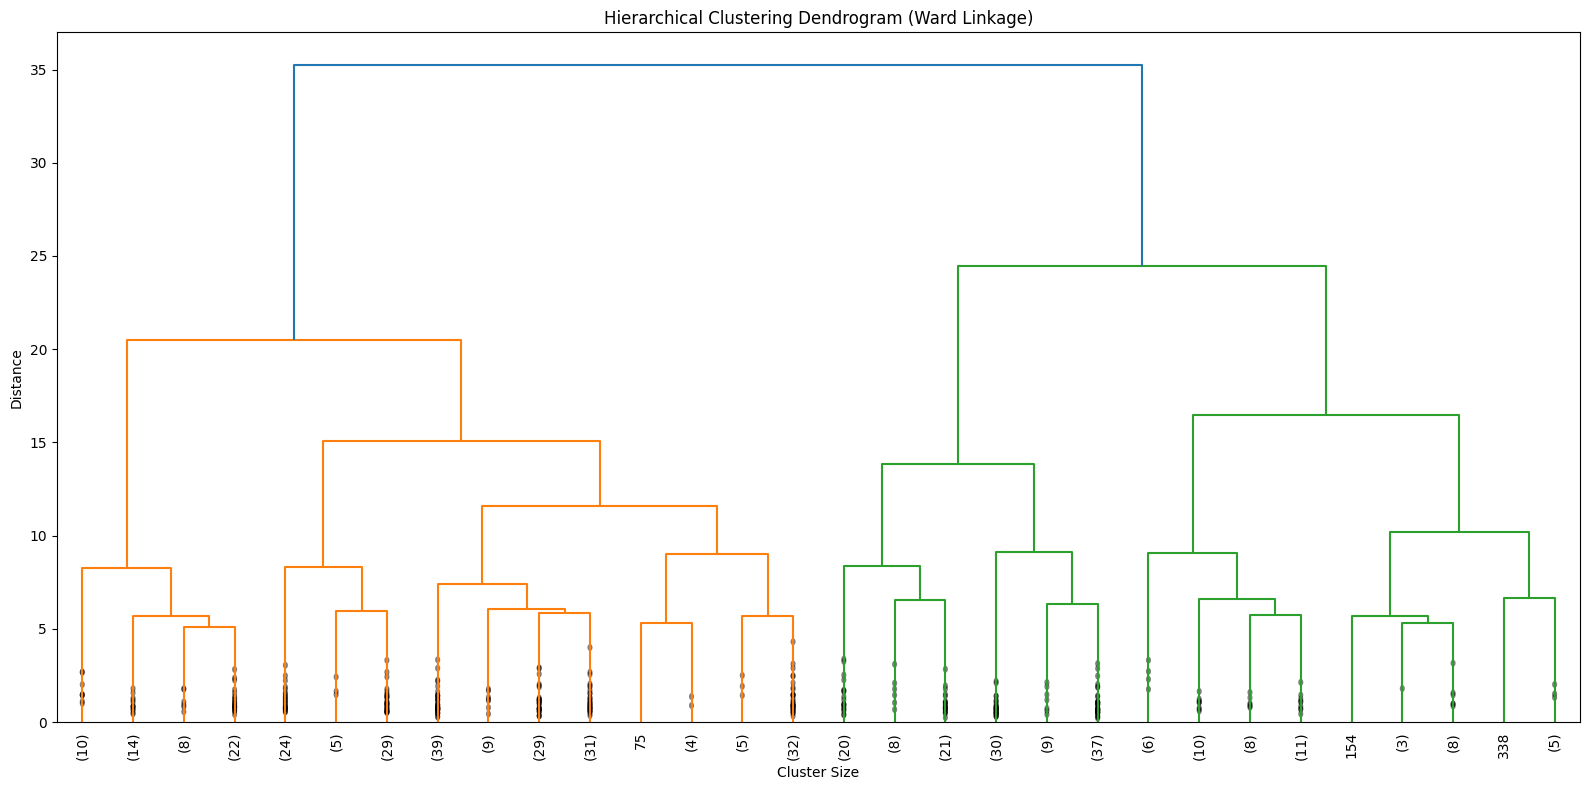

In [26]:
plt.figure(figsize=(16, 8))
Z = linkage(X, method='ward')
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=10, show_contracted=True)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

**DBSCAN**

In [27]:
eps_values = [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]
min_samples_values = [3, 5, 7, 10]

dbscan_results = []
for eps in eps_values:
    for ms in min_samples_values:
        db = DBSCAN(eps=eps, min_samples=ms)
        labels_db = db.fit_predict(X)
        n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
        n_noise = (labels_db == -1).sum()
        sil = silhouette_score(X, labels_db) if n_clusters >= 2 else -1
        dbscan_results.append({'eps': eps, 'min_samples': ms, 'n_clusters': n_clusters,
                               'n_noise': n_noise, 'silhouette': round(sil, 4)})

dbscan_df = pd.DataFrame(dbscan_results)
print(dbscan_df.to_string(index=False))

 eps  min_samples  n_clusters  n_noise  silhouette
0.50            3           8      396     -0.3993
0.50            5           1      435     -1.0000
0.50            7           0      440     -1.0000
0.50           10           0      440     -1.0000
0.75            3           9      218     -0.3170
0.75            5           4      281     -0.2599
0.75            7           3      323     -0.1475
0.75           10           3      385     -0.2741
1.00            3           6       91     -0.1616
1.00            5           1      124     -1.0000
1.00            7           2      134      0.0608
1.00           10           1      170     -1.0000
1.25            3           2       53      0.0712
1.25            5           1       70     -1.0000
1.25            7           1       74     -1.0000
1.25           10           1       84     -1.0000
1.50            3           2       35      0.2989
1.50            5           1       41     -1.0000
1.50            7           1  

In [28]:
opt_row = dbscan_df[dbscan_df['n_clusters'] >= 2].sort_values('silhouette', ascending=False).iloc[0]
print(f"Best DBSCAN: eps={opt_row['eps']}, min_samples={int(opt_row['min_samples'])}")
print(f"  Clusters: {int(opt_row['n_clusters'])}, Noise: {int(opt_row['n_noise'])}, Silhouette: {opt_row['silhouette']}")

db_best = DBSCAN(eps=opt_row['eps'], min_samples=int(opt_row['min_samples']))
labels_dbscan = db_best.fit_predict(X)

Best DBSCAN: eps=1.5, min_samples=3
  Clusters: 2, Noise: 35, Silhouette: 0.2989


In [29]:
dbscan_model = DBSCAN(eps=1.5, min_samples=3)
dbscan_model.fit(X)

,"eps eps: float, default=0.5The maximum distance between two samples for one to be consideredas in the neighborhood of the other. This is not a maximum boundon the distances of points within a cluster. This is the mostimportant DBSCAN parameter to choose appropriately for your data setand distance function. Smaller values generally lead to more clusters.",1.5
,"min_samples min_samples: int, default=5The number of samples (or total weight) in a neighborhood for a point tobe considered as a core point. This includes the point itself. If`min_samples` is set to a higher value, DBSCAN will find denser clusters,whereas if it is set to a lower value, the found clusters will be moresparse.",3
,"metric metric: str, or callable, default='euclidean'The metric to use when calculating distance between instances in afeature array. If metric is a string or callable, it must be one ofthe options allowed by :func:`sklearn.metrics.pairwise_distances` forits metric parameter.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors for DBSCAN... versionadded:: 0.17 metric *precomputed* to accept precomputed sparse matrix.",'euclidean'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function... versionadded:: 0.19",None
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'The algorithm to be used by the NearestNeighbors moduleto compute pointwise distances and find nearest neighbors.'auto' will attempt to decide the most appropriate algorithmbased on the values passed to :meth:`fit` method.See :class:`~sklearn.neighbors.NearestNeighbors` documentation fordetails.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or cKDTree. This can affect the speedof the construction and query, as well as the memory requiredto store the tree. The optimal value dependson the nature of the problem.",30
,"p p: float, default=NoneThe power of the Minkowski metric to be used to calculate distancebetween points. If None, then ``p=2`` (equivalent to the Euclideandistance). When p=1, this is equivalent to Manhattan distance.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


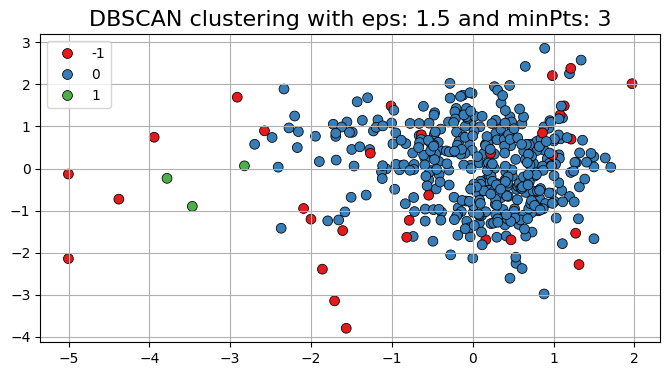

In [30]:
plt.figure(figsize=(8,4))
sns.scatterplot(x=X[:,0], y=X[:,1], hue=labels_dbscan, palette='Set1', s=50, edgecolor='k')
plt.title(f"DBSCAN clustering with eps: {1.5} and minPts: {3}", fontsize=16)
plt.grid()
plt.show()

**Comparison of Models**

In [31]:
comparison = pd.DataFrame({
    'Method': ['K-Means (k=2)', 'K-Means (k=3)',
               'Agglomerative (k=2)', 'Agglomerative (k=3)',
               f"DBSCAN (eps={opt_row['eps']}, ms={int(opt_row['min_samples'])})"],
    'Silhouette Score': [
        silhouette_score(X, labels_km2),
        silhouette_score(X, labels_km3),
        silhouette_score(X, y_pred_agg),
        silhouette_score(X, y_pred_agg_c2),
        opt_row['silhouette']
    ]
})
comparison = comparison.sort_values('Silhouette Score', ascending=False)
print(comparison.to_string(index=False))

                Method  Silhouette Score
DBSCAN (eps=1.5, ms=3)          0.298900
         K-Means (k=2)          0.290328
         K-Means (k=3)          0.259409
   Agglomerative (k=3)          0.258495
   Agglomerative (k=2)          0.254657


## 5 Cluster Profiling & Communication

In [40]:
customer_df['Cluster'] = labels_km2

print('Cluster distribution:')
print(customer_df['Cluster'].value_counts().sort_index())

Cluster distribution:
Cluster
0    188
1    252
Name: count, dtype: int64


In [41]:
print('=== Mean Spending per Cluster ===')
cluster_means = customer_df.groupby('Cluster')[class_cols].mean().round(1)
print(cluster_means)
print()

print('=== Median Spending per Cluster ===')
cluster_medians = customer_df.groupby('Cluster')[class_cols].median().round(1)
print(cluster_medians)

=== Mean Spending per Cluster ===
           Fresh     Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                 
0         9355.9  10346.4  14697.1  2222.5            6084.5      2177.4
1        13973.1   2401.8   2918.7  3705.7             491.9      1038.0

=== Median Spending per Cluster ===
           Fresh    Milk  Grocery  Frozen  Detergents_Paper  Delicassen
Cluster                                                                
0         5406.5  7690.5  11527.0  1061.5            4495.0      1388.5
1        10347.5  1871.0   2406.0  2225.0             327.5       749.5


In [42]:
print('=== Channel Distribution per Cluster ===')
print(pd.crosstab(customer_df['Cluster'], customer_df['Channel'], normalize='index').round(3))
print()

print('=== Region Distribution per Cluster ===')
print(pd.crosstab(customer_df['Cluster'], customer_df['Region'], normalize='index').round(3))

=== Channel Distribution per Cluster ===
Channel      1      2
Cluster              
0        0.287  0.713
1        0.968  0.032

=== Region Distribution per Cluster ===
Region       1      2      3
Cluster                     
0        0.154  0.101  0.745
1        0.190  0.111  0.698


PCA

Explained variance ratio: [0.4408 0.2719]
Total variance explained: 0.7127


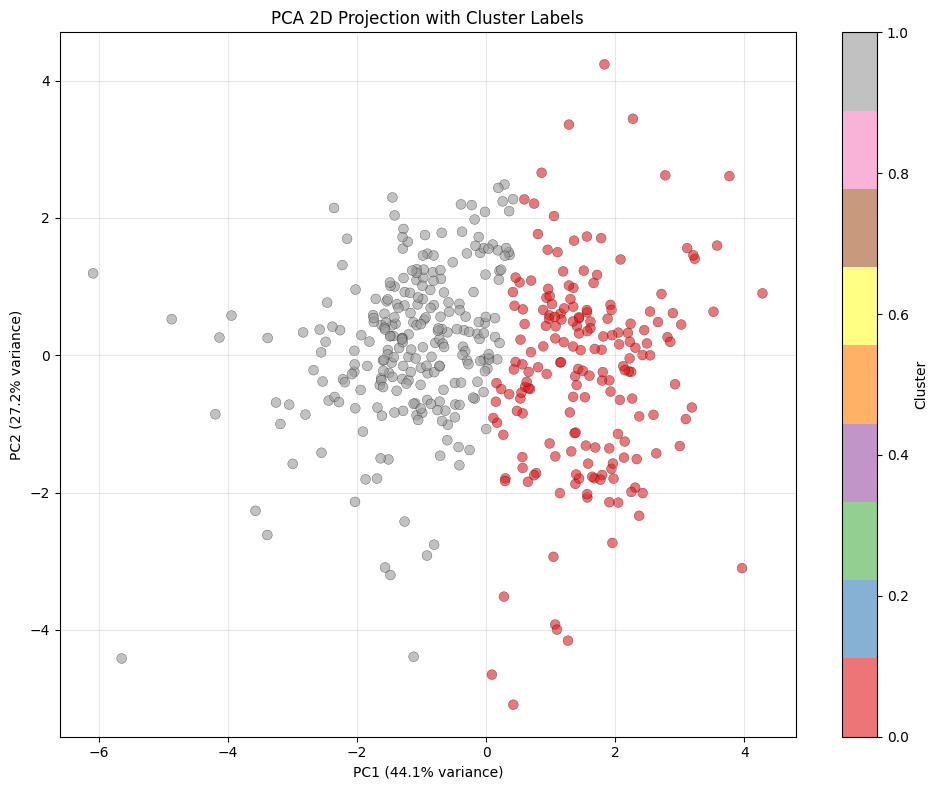

In [43]:
pca = PCA(n_components=2, random_state=402)
X_pca = pca.fit_transform(X)

print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.4f}')

plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_df['Cluster'],
                      cmap='Set1', alpha=0.6, s=50, edgecolors='k', linewidth=0.3)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title('PCA 2D Projection with Cluster Labels')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()